In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Jupyter requires matplotlib to display images inline
%matplotlib inline

def show_img(img, title="Image", cmap=None):
    """Helper to display OpenCV images in Jupyter"""
    plt.figure(figsize=(12, 8))
    if len(img.shape) == 3:
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        # Grayscale/Mask
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [2]:
CONFIG = {
    # Input Image
    "IMAGE_PATH": "test_image/sawi_1.jpg",  # <--- REPLACE WITH YOUR IMAGE PATH
    
    # Model
    "YOLO_WEIGHTS": "./runs/detect/train2/weights/best.pt", 
    "YOLO_CONF": 0.55,
    "IMG_SIZE": 640,
    
    # Calibration (ArUco)
    "ARUCO_DICT": cv2.aruco.DICT_4X4_50,
    "MARKER_SIZE_CM": 6.8,  # Size of the printed square in cm
    
    # Color Segmentation (HSV) for Plant (Green)
    "H_MIN": 30, "S_MIN": 40,  "V_MIN": 40,
    "H_MAX": 90, "S_MAX": 255, "V_MAX": 255,
}

In [3]:
def get_curved_length_and_mask(img_crop, pixels_per_cm):
    """
    1. Segments green color.
    2. Finds contour.
    3. Fits a rotated rectangle (MinAreaRect).
    4. Returns length in cm and the binary mask.
    """
    if img_crop is None or img_crop.size == 0 or pixels_per_cm is None:
        return 0.0, None

    # 1. Convert to HSV
    hsv = cv2.cvtColor(img_crop, cv2.COLOR_BGR2HSV)
    lower = np.array([CONFIG["H_MIN"], CONFIG["S_MIN"], CONFIG["V_MIN"]])
    upper = np.array([CONFIG["H_MAX"], CONFIG["S_MAX"], CONFIG["V_MAX"]])
    
    # 2. Create Mask
    mask = cv2.inRange(hsv, lower, upper)
    
    # Clean noise (Morphological operations)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 3. Find Contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return 0.0, mask

    # Get the largest object (The Plant)
    c = max(contours, key=cv2.contourArea)

    # 4. MinAreaRect (Rotated Bounding Box)
    rect = cv2.minAreaRect(c)
    (center, (w, h), angle) = rect
    
    # The length is the longer side of the box
    length_px = max(w, h)
    
    return length_px / pixels_per_cm, mask

Loading YOLO Model...
Model Loaded.


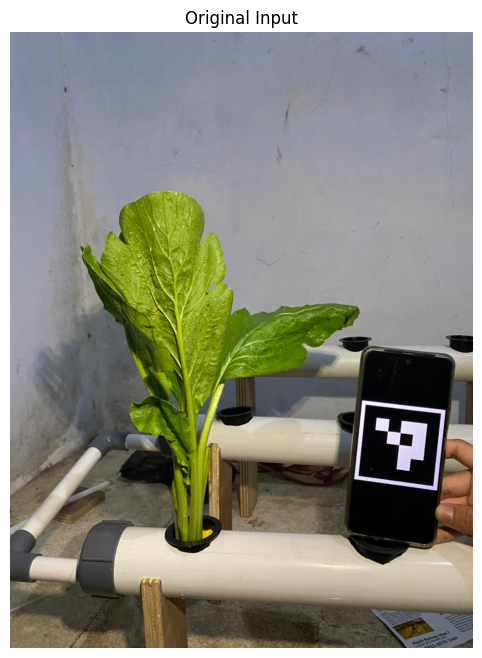

In [4]:
# 1. Load Image
frame = cv2.imread(CONFIG["IMAGE_PATH"])
if frame is None:
    raise FileNotFoundError(f"Could not load image at {CONFIG['IMAGE_PATH']}")

h, w = frame.shape[:2]
vis_frame = frame.copy() # We will draw on this
full_mask = np.zeros((h, w), dtype=np.uint8) # Canvas for the mask

# 2. Load Model
print("Loading YOLO Model...")
model = YOLO(CONFIG["YOLO_WEIGHTS"])
print("Model Loaded.")

# Show original image
show_img(frame, "Original Input")

In [5]:
# Setup ArUco
aruco_dict = cv2.aruco.getPredefinedDictionary(CONFIG['ARUCO_DICT'])
aruco_params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

# Detect
corners, ids, rejected = detector.detectMarkers(frame)

pixels_per_cm = None
marker_center_x = None

if ids is not None:
    # Find the largest marker (in case there are false positives)
    areas = [cv2.contourArea(c[0]) for c in corners]
    idx = np.argmax(areas)
    mk = corners[idx][0]
    
    # Draw Marker on Visual Frame
    cv2.polylines(vis_frame, [mk.astype(int)], True, (0, 255, 255), 3)
    
    # Calculate Scale
    width_px = np.linalg.norm(mk[0] - mk[1])
    pixels_per_cm = width_px / CONFIG['MARKER_SIZE_CM']
    
    # Calculate Center X (for Left/Right logic)
    marker_center_x = np.mean(mk[:, 0])
    
    print(f"Marker Detected: ID {ids[idx]}")
    print(f"Calibration: {pixels_per_cm:.2f} pixels/cm")
    print(f"Marker Center X: {marker_center_x:.0f}")
else:
    print("WARNING: No ArUco marker found. Measurements will be 0.0 cm.")

Marker Detected: ID [0]
Calibration: 25.81 pixels/cm
Marker Center X: 808



0: 640x480 1 sawi, 195.1ms
Speed: 139.4ms preprocess, 195.1ms inference, 18.0ms postprocess per image at shape (1, 3, 640, 480)
Found 1 plants.


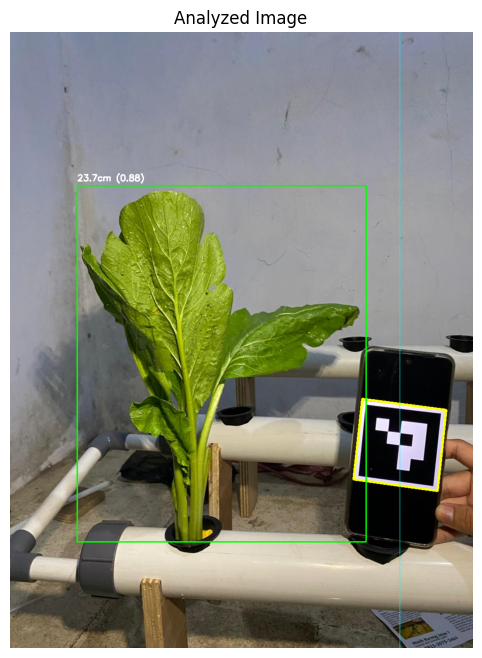

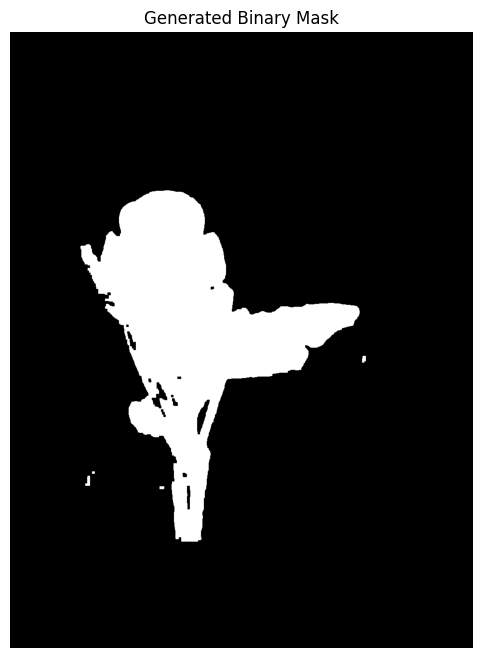

In [6]:
# 1. Run YOLO Inference
results = model.predict(frame, conf=CONFIG["YOLO_CONF"], imgsz=CONFIG["IMG_SIZE"])

detections = []
if results and results[0].boxes:
    detections = results[0].boxes

print(f"Found {len(detections)} plants.")

# 2. Process each plant
for box in detections:
    # Get coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    conf = float(box.conf[0])
    
    # Boundary checks
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    
    # --- Logic: Filter by Side (Optional) ---
    # If we found a marker, we can check if the plant is aligned with it
    # For now, we will process ALL plants, but draw a line for the marker center
    if marker_center_x:
        side = "Right" if ((x1+x2)/2) > marker_center_x else "Left"
        # You could add 'continue' here if you want to ignore one side
    
    # --- Measure ---
    length_cm = 0.0
    
    if pixels_per_cm:
        # Crop the plant
        plant_crop = frame[y1:y2, x1:x2]
        
        # Calculate
        length_cm, crop_mask = get_curved_length_and_mask(plant_crop, pixels_per_cm)
        
        # Add to Full Mask Canvas
        if crop_mask is not None:
            mh, mw = crop_mask.shape
            # Paste the small mask into the big black image
            roi = full_mask[y1:y1+mh, x1:x1+mw]
            full_mask[y1:y1+mh, x1:x1+mw] = cv2.bitwise_or(roi, crop_mask)
            
            # Optional: Draw the rotated rectangle on the main image for debug
            # (To do this strictly, we'd need to pass 'vis_frame' into the function like the original code,
            # or just rely on the mask visualization).
            
    # --- Draw UI ---
    # Box
    cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Text
    label = f"{length_cm:.1f}cm ({conf:.2f})"
    cv2.putText(vis_frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)


# --- Final Display ---
if marker_center_x:
    # Draw the dividing line
    cv2.line(vis_frame, (int(marker_center_x), 0), (int(marker_center_x), h), (255, 255, 0), 1)

# Show Result
show_img(vis_frame, "Analyzed Image")

# Show Mask
show_img(full_mask, "Generated Binary Mask", cmap='gray')